## Document Forgery Detection: Machine Learning Classification Report

### Overview

This notebook trains and evaluates a Random Forest model for forged-document detection using features produced by `dataset_builder.py / feature_engineering.py`.
The report emphasizes stakeholder-ready evidence for banking use cases:
- **Accuracy and class-level quality** (precision, recall, F1-score)
- **Confusion matrix** on on both hold-out and generated train/validation/testing data
- **Risk-oriented metrics** like false positive/negative rates
- **Model explainability** via top forensic indicators


In [83]:
import json
import os
from pathlib import Path
import joblib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_fscore_support,
    roc_auc_score,
)

from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")


In [84]:
# Load datasets generated from `training_set` / `validation_set` / `testing_set`
TRAIN_DATASET_PATH = "dataset_outputs/train.csv"
VALIDATION_DATASET_PATH = "dataset_outputs/val.csv"
TEST_DATASET_PATH = "dataset_outputs/test.csv"

if not Path(TRAIN_DATASET_PATH).exists():
    raise FileNotFoundError(f"Missing required dataset: {TRAIN_DATASET_PATH}")

assert Path(VALIDATION_DATASET_PATH).exists(), "Validation dataset is required."
assert Path(TEST_DATASET_PATH).exists(), "Test dataset is required."

df_train_raw = pd.read_csv(TRAIN_DATASET_PATH)
df_validation = pd.read_csv(VALIDATION_DATASET_PATH)
df_test = pd.read_csv(TEST_DATASET_PATH)

print("Training dataset shape:", df_train_raw.shape)
print("Validation dataset shape:", df_validation.shape)
print("Test dataset shape:", df_test.shape)

display(df_train_raw.head())

print("Training label distribution:")
print(df_train_raw["Label"].value_counts())
assert df_train_raw["Label"].nunique() == 2, (
    "Dataset contains only one class; forgery detection requires genuine + forged examples."
)

print("Validation label distribution:")
print(df_validation["Label"].value_counts())

print("Test label distribution:")
print(df_test["Label"].value_counts())


Training dataset shape: (315, 28)
Validation dataset shape: (69, 28)
Test dataset shape: (66, 28)


,Char_Count,NER_Detected_Count,NER_Completeness_Ratio,H_Mean,H_STD,W_Mean,W_STD,AR_Mean,AR_STD,Ink_Mean,...,OCR_Box_Anomalies_Count,BG_Anomaly_Line_Count,Clustered_Regions_Count,Font_Size_Variance,OCR_Confidence_Mean,Field_Blur_Variance,Risk_Score,Image_Name,Country_Code,Label
0,893,0,0.818182,14.451288,17.130980,9.912654,13.306078,0.727740,0.418665,201.286954,...,1,0,129,293.470471,0.940051,1.009219e+06,100.0,alb_id_00.jpg,ALB,0
1,824,0,0.818182,14.705097,17.851237,10.382282,15.447082,0.728576,0.418560,201.264769,...,1,0,120,318.666673,0.938399,1.190953e+06,100.0,alb_id_00_fake_6_25.jpg,ALB,1
2,881,0,0.727273,15.087401,18.115353,10.300795,14.334788,0.725030,0.402693,201.074540,...,2,0,131,328.166027,0.962368,1.470930e+06,100.0,alb_id_01.jpg,ALB,0
3,897,0,0.727273,14.841695,17.409281,10.225195,14.090348,0.727088,0.392937,201.249565,...,2,0,127,303.083078,0.961881,1.111626e+06,100.0,alb_id_01_fake_6_56.jpg,ALB,1
4,957,0,0.727273,14.386625,16.337255,9.853710,13.400179,0.724360,0.389191,200.817650,...,2,0,142,266.905903,0.962347,1.627169e+06,100.0,alb_id_01_fake_6_61.jpg,ALB,1


Training label distribution:
Label
1    168
0    147
Name: count, dtype: int64
Validation label distribution:
Label
0    35
1    34
Name: count, dtype: int64
Test label distribution:
Label
1    39
0    27
Name: count, dtype: int64


In [85]:
# =========================
# STEP 1: Split Features & Labels
# =========================

# Training set
X_train = df_train_raw.drop(columns=["Label"])
y_train = df_train_raw["Label"]

# Validation set
assert df_validation is not None, "Validation dataset is required"
X_val = df_validation.drop(columns=["Label"])
y_val = df_validation["Label"]

# Test set
assert df_test is not None, "Test dataset is required"
X_test = df_test.drop(columns=["Label"])
y_test = df_test["Label"]

print("Dataset Shapes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Dataset Shapes:
Train: (315, 27)
Validation: (69, 27)
Test: (66, 27)


In [86]:
# Feature / Target Split + categorical encoding
DROP_COLUMNS = ["Document_ID"]
X_train_raw = X_train.drop(columns=DROP_COLUMNS, errors="ignore")
X_val_raw = X_val.drop(columns=DROP_COLUMNS, errors="ignore")
X_test_raw = X_test.drop(columns=DROP_COLUMNS, errors="ignore")

y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

# Handle non-numeric features (e.g., Country_Code='LVA')
categorical_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns detected:", categorical_cols if categorical_cols else "None")

X_train = pd.get_dummies(X_train_raw, columns=categorical_cols, drop_first=False)
X_val = pd.get_dummies(X_val_raw, columns=categorical_cols, drop_first=False)
X_test = pd.get_dummies(X_test_raw, columns=categorical_cols, drop_first=False)

# Ensure feature consistency across splits
if not (set(X_train.columns) == set(X_val.columns) == set(X_test.columns)):
    X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Encoded feature count:", X_train.shape[1])
print("Sample encoded feature columns:", X_train.columns[:10].tolist())


Categorical columns detected: ['Image_Name', 'Country_Code']
Encoded feature count: 343
Sample encoded feature columns: ['Char_Count', 'NER_Detected_Count', 'NER_Completeness_Ratio', 'H_Mean', 'H_STD', 'W_Mean', 'W_STD', 'AR_Mean', 'AR_STD', 'Ink_Mean']


### Train/Test Split (70:30 Ratio)

In [87]:
# Dataset split summary (predefined train/validation/test files)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))


Training samples: 315
Validation samples: 69
Testing samples: 66


### Baseline Model (Majority Class Predictor)


In [88]:
# =========================
# BASELINE MODEL (Majority Class)
# =========================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

# Baseline model: predicts most frequent class
baseline_model = DummyClassifier(strategy="most_frequent")

# Fit ONLY on training labels (no real learning)
baseline_model.fit(X_train, y_train)

print("[INFO] Baseline model (Majority Class) initialized.")


[INFO] Baseline model (Majority Class) initialized.


In [89]:
# =========================
# BASELINE - VALIDATION PERFORMANCE
# =========================

val_pred_baseline = baseline_model.predict(X_val)

val_acc_baseline = accuracy_score(y_val, val_pred_baseline)

print("\n[BASELINE VALIDATION RESULTS]")
print(f"Accuracy: {val_acc_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, val_pred_baseline))



[BASELINE VALIDATION RESULTS]
Accuracy: 0.4928

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        35
           1       0.49      1.00      0.66        34

    accuracy                           0.49        69
   macro avg       0.25      0.50      0.33        69
weighted avg       0.24      0.49      0.33        69



In [90]:
# =========================
# BASELINE - TEST PERFORMANCE
# =========================

test_pred_baseline = baseline_model.predict(X_test)

test_acc_baseline = accuracy_score(y_test, test_pred_baseline)

print("\n[BASELINE TEST RESULTS]")
print(f"Accuracy: {test_acc_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_pred_baseline))



[BASELINE TEST RESULTS]
Accuracy: 0.5909

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.59      1.00      0.74        39

    accuracy                           0.59        66
   macro avg       0.30      0.50      0.37        66
weighted avg       0.35      0.59      0.44        66



### Random Forest Classifier Training

In [104]:
# =========================
# STEP 2: Train Model
# =========================

model = RandomForestClassifier(
    n_estimators=350,
    max_depth=12,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
)
model.fit(X_train, y_train)

print("[INFO] Model trained on TRAINING set only. Random Forest model training complete")


[INFO] Model trained on TRAINING set only. Random Forest model training complete


In [111]:
# =========================
# STEP 3: Validation Evaluation
# =========================
from sklearn import metrics

def evaluate_classifier(model, X_eval, y_eval, dataset_name="Dataset"):
    preds = model.predict(X_eval)
    probs = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else None

    precision, recall, f1, _ = precision_recall_fscore_support(
       y_eval,
       preds,
       average='binary',
       zero_division=0,
       )

    metrics = {
        "dataset": dataset_name,
        "accuracy": float(accuracy_score(y_eval, preds)),
        "balanced_accuracy": float(balanced_accuracy_score(y_eval, preds)),
        "precision" : float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "mcc": float(matthews_corrcoef(y_eval, preds)),
        "roc_auc": float(roc_auc_score(y_eval, probs)) if probs is not None else None,
        "classification_report" : classification_report(
            y_eval,
            preds,
            target_names=["Genuine", "Forged"],
            output_dict=True,
            zero_division=0,
            )
     }

    tn, fp, fn, tp = confusion_matrix(y_eval, preds).ravel()
    metrics.update(
        {
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0,
            "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0,
        }
    )

    print(f"=== RANDOM FOREST RESULTS ({dataset_name}) ===")
    print(f"Accuracy:           {metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy:  {metrics['balanced_accuracy']:.4f}")
    print(f"Precision:          {metrics['precision']:.4f}")
    print(f"Recall:             {metrics['recall']:.4f}")
    print(f"F1-Score:           {metrics['f1_score']:.4f}")
    print(f"MCC:                {metrics['mcc']:.4f}")
    if metrics["roc_auc"] is not None:
        print(f"ROC AUC:        {metrics['roc_auc']:.4f}")
    print(f"FPR / FNR:         {metrics['false_positive_rate']:.4f} / {metrics['false_negative_rate']:.4f}")
    print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(classification_report(y_eval, preds, target_names=["Genuine", "Forged"], zero_division=0))

    return preds, metrics

val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)

_, validation_metrics = evaluate_classifier(model, X_val, y_val, dataset_name="Validation Set")


=== RANDOM FOREST RESULTS (Validation Set) ===
Accuracy:           0.8116
Balanced Accuracy:  0.8130
Precision:          0.7561
Recall:             0.9118
F1-Score:           0.8267
MCC:                0.6374
ROC AUC:        0.8824
FPR / FNR:         0.2857 / 0.0882
Confusion Matrix: TN=25, FP=10, FN=3, TP=31
              precision    recall  f1-score   support

     Genuine       0.89      0.71      0.79        35
      Forged       0.76      0.91      0.83        34

    accuracy                           0.81        69
   macro avg       0.82      0.81      0.81        69
weighted avg       0.83      0.81      0.81        69



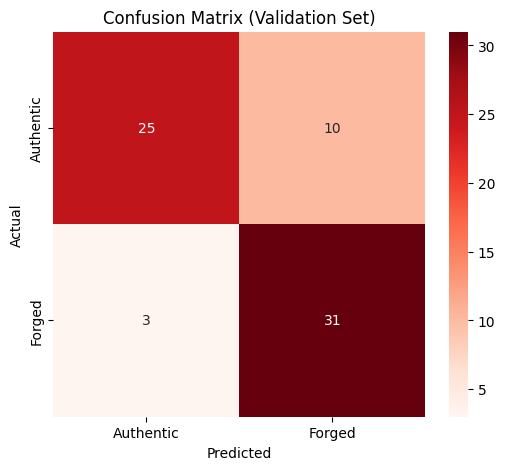

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Authentic", "Forged"],
            yticklabels=["Authentic", "Forged"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation Set)")
plt.show()


#### Save the Trained Model

This avoids having to retrain the model every time you want to make a prediction.

In [93]:
MODEL_DIR = "trained_models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "forged_document_rf_model.pkl")
joblib.dump(model, model_path)
print(f"Trained model saved to: {model_path}")


Trained model saved to: trained_models\forged_document_rf_model.pkl


In [94]:
# Save feature column order for consistent inference
feature_columns_path = os.path.join(MODEL_DIR, "feature_columns.pkl")
joblib.dump(list(X_train.columns), feature_columns_path)

print(f"Feature column order saved to: {feature_columns_path}")
metrics_path = os.path.join(MODEL_DIR, "training_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump({"validation_set": validation_metrics}, f, indent=2)
print(f"Validation metrics saved to: {metrics_path}")


Feature column order saved to: trained_models\feature_columns.pkl
Validation metrics saved to: trained_models\training_metrics.json


### Key Results and Risk Signals for Banking Stakeholders

The next sections provide model evidence relevant to financial institutions:
- How many genuine documents may be wrongly blocked (**False Positives**)
- How many forged documents may pass undetected (**False Negatives**)
- Which forensic signals contribute most to automated screening decisions

### Confusion Matrix (Hold-out Test Set)

The Confusion Matrix visually represents the model's performance on the testing set, detailing true positives, true negatives, and classification errors.

In [107]:
# =========================
# STEP 4: Final Test Evaluation
# =========================

from sklearn.metrics import confusion_matrix

test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

_, testing_metrics = evaluate_classifier(model, X_test, y_test, dataset_name="Test Set")

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump({"validation_set": validation_metrics, "testing_set": testing_metrics}, f, indent=2)

print(f"Updated metrics saved to: {metrics_path}")


=== RANDOM FOREST RESULTS (Test Set) ===
Accuracy:           0.7727
Balanced Accuracy:  0.7336
Precision:          0.7400
Recall:             0.9487
F1-Score:           0.8315
MCC:                0.5361
ROC AUC:        0.8148
FPR / FNR:         0.4815 / 0.0513
Confusion Matrix: TN=14, FP=13, FN=2, TP=37
              precision    recall  f1-score   support

     Genuine       0.88      0.52      0.65        27
      Forged       0.74      0.95      0.83        39

    accuracy                           0.77        66
   macro avg       0.81      0.73      0.74        66
weighted avg       0.80      0.77      0.76        66

Updated metrics saved to: trained_models\training_metrics.json


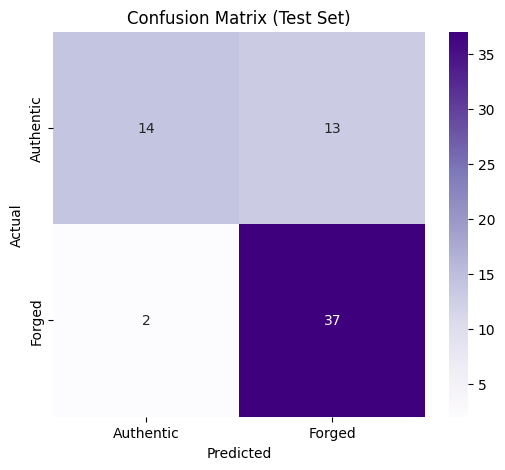

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Authentic", "Forged"],
            yticklabels=["Authentic", "Forged"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()


In [97]:
# =========================
# MODEL COMPARISON
# =========================

print("\n==============================")
print(" BASELINE vs TRAINED MODEL")
print("==============================")

print(f"Baseline Test Accuracy : {test_acc_baseline:.4f}")
print(f"Trained Model Accuracy : {test_acc:.4f}")

improvement = test_acc - test_acc_baseline

print(f"\nImprovement: {improvement:.4f} ({improvement*100:.2f}%)")



 BASELINE vs TRAINED MODEL
Baseline Test Accuracy : 0.5909
Trained Model Accuracy : 0.7727

Improvement: 0.1818 (18.18%)


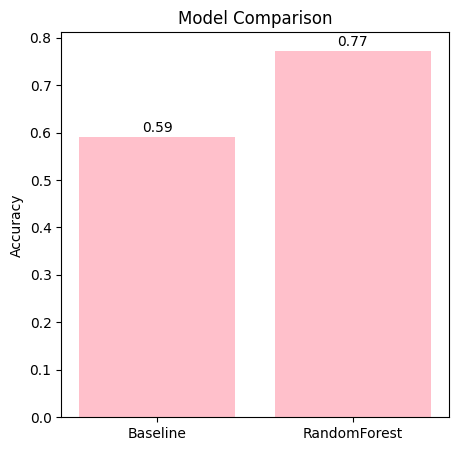

In [130]:
import matplotlib.pyplot as plt

models = ["Baseline", "RandomForest"]
accuracies = [test_acc_baseline, test_acc]

plt.figure(figsize=(5,5))
plt.bar(models, accuracies, color= "Pink")

plt.ylabel("Accuracy")
plt.title("Model Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()


#### Feature Importance

This chart highlights the most influential forensic features used by the Random Forest model. These indicators can guide compliance teams when prioritizing manual review and fraud controls.

In [99]:
importances = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(15)


Field_Blur_Variance    0.078468
W_Mean                 0.058290
Ink_Density_Mean       0.054865
W_STD                  0.048125
AR_Mean                0.045911
BG_STD                 0.045187
Char_Count             0.042566
Grad_STD               0.042460
Ink_Anomaly_Ratio      0.042340
Geo_Anomaly_Ratio      0.041129
H_STD                  0.040139
AR_STD                 0.039506
Font_Size_Variance     0.038901
OCR_Confidence_Mean    0.037292
H_Mean                 0.035559
dtype: float64

In [100]:
results = X_test.copy()
results["True_Label"] = y_test.values
results["Predicted_Label"] = test_pred

errors = results[results["True_Label"] != results["Predicted_Label"]]
print("Misclassified test samples:", len(errors))

errors.head()


Misclassified test samples: 15


,Char_Count,NER_Detected_Count,NER_Completeness_Ratio,H_Mean,H_STD,W_Mean,W_STD,AR_Mean,AR_STD,Ink_Mean,...,Image_Name_svk_id_46_fake_8_98.jpg,Image_Name_svk_id_47.jpg,Image_Name_svk_id_47_fake_8_20.jpg,Image_Name_svk_id_47_fake_8_31.jpg,Image_Name_svk_id_47_fake_8_48.jpg,Country_Code_ALB,Country_Code_LVA,Country_Code_SVK,True_Label,Predicted_Label
1,982,0,0.818182,13.707739,14.785194,9.266802,13.226220,0.705879,0.405873,199.289496,...,0,0,0,0,0,True,False,False,1,0
2,529,0,0.727273,14.650284,17.771938,9.621928,12.470486,0.702534,0.379112,200.191581,...,0,0,0,0,0,True,False,False,0,1
4,744,0,0.636364,13.357527,15.235292,9.655914,11.932940,0.765163,0.391512,201.714234,...,0,0,0,0,0,True,False,False,0,1
8,767,0,0.818182,13.741851,17.621061,9.668840,12.549037,0.756660,0.382866,203.762513,...,0,0,0,0,0,True,False,False,0,1
11,772,0,0.818182,15.522021,19.903674,10.007772,14.386682,0.678868,0.373197,203.423251,...,0,0,0,0,0,True,False,False,0,1


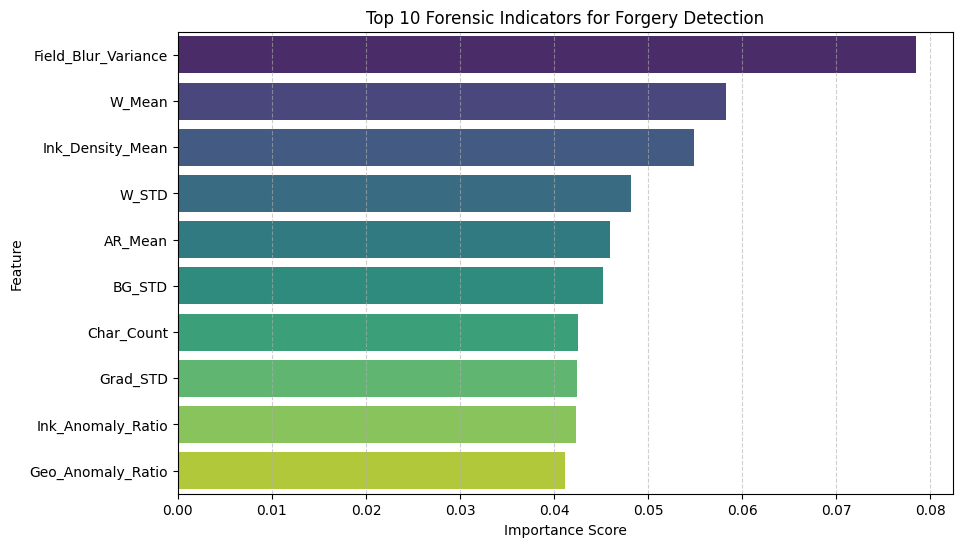

In [101]:
# Top 10 forensic indicator
top_features = importances.nlargest(10)
plt.figure(figsize=(10, 6))
top_features = importances.nlargest(10)
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title('Top 10 Forensic Indicators for Forgery Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [102]:
# Executive-ready summary table
summary_rows = [
    {
        "Dataset": "Validation Set",
        "Accuracy": validation_metrics["accuracy"],
        "Balanced Accuracy": validation_metrics["balanced_accuracy"],
        "Precision": validation_metrics["precision"],
        "Recall": validation_metrics["recall"],
        "F1-Score": validation_metrics["f1_score"],
        "False Positive Rate": validation_metrics["false_positive_rate"],
        "False Negative Rate": validation_metrics["false_negative_rate"],
    },
    {
        "Dataset": "Testing Set",
        "Accuracy": testing_metrics["accuracy"],
        "Balanced Accuracy": testing_metrics["balanced_accuracy"],
        "Precision": testing_metrics["precision"],
        "Recall": testing_metrics["recall"],
        "F1-Score": testing_metrics["f1_score"],
        "False Positive Rate": testing_metrics["false_positive_rate"],
        "False Negative Rate": testing_metrics["false_negative_rate"],
    },
]

summary_df = pd.DataFrame(summary_rows)
summary_df.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "False Positive Rate": "{:.4f}",
        "False Negative Rate": "{:.4f}",
})


,Dataset,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,False Positive Rate,False Negative Rate
0,Validation Set,0.8116,0.8130,0.7561,0.9118,0.8267,0.2857,0.0882
1,Testing Set,0.7727,0.7336,0.7400,0.9487,0.8315,0.4815,0.0513


In [103]:
import pickle

MODEL_PATH = "trained_models/forged_document_rf_model.pkl"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(model, f)

print(f"[INFO] Model saved to {MODEL_PATH}")


[INFO] Model saved to trained_models/forged_document_rf_model.pkl
